# Install & Imports

In [1]:
!pip install tensorflow==2.15.0 --quiet

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0


In [2]:
import os
import glob
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers

import matplotlib.pyplot as plt
from typing import Dict, List, Tuple

# Mount Drive


In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


# Dataset Paths & Auto-Discovery

In [4]:
BASE_DATASET_DIR = "/users/"

def auto_find_dataset(folder_prefix: str) -> str:
    pattern = os.path.join(BASE_DATASET_DIR, f"{folder_prefix}*")
    matches = glob.glob(pattern)
    if len(matches) == 0:
        raise ValueError(f"No folder found for prefix: {folder_prefix} under {BASE_DATASET_DIR}")
    return matches[0]

DATASET_PATHS = {
    "CSE-CIC-IDS2018":      auto_find_dataset("CSE_CIC_IDS2018"),
    "CIC_IIoT_2025":        auto_find_dataset("CIC_IIoT_2025"),
    "CIC_BCCC_IoMT_2024":   auto_find_dataset("CIC_BCCC_NRC_IoMT_2024"),
    "Combined":             auto_find_dataset("Combined"),
}

print("✅ Resolved dataset paths:")
for k, v in DATASET_PATHS.items():
    print(f"{k:22s} -> {v}")

✅ Resolved dataset paths:
CSE-CIC-IDS2018        -> /users/
CIC_IIoT_2025          -> /users/
CIC_BCCC_IoMT_2024     -> /users/
Combined               -> /users/


# Dataset Loader (using latent features)

In [5]:
def load_dataset(dataset_name: str):
    if dataset_name not in DATASET_PATHS:
        raise ValueError(f"Unknown dataset_name: {dataset_name}")

    path = DATASET_PATHS[dataset_name]

    if dataset_name == "Combined":
        x_train_file = "combined_train_latent.npy"
        x_val_file   = "combined_val_latent.npy"
        x_test_file  = "combined_test_latent.npy"
        y_train_file = "combined_y_train.npy"
        y_val_file   = "combined_y_val.npy"
        y_test_file  = "combined_y_test.npy"
    else:
        x_train_file = "train_latent.npy"
        x_val_file   = "val_latent.npy"
        x_test_file  = "test_latent.npy"
        y_train_file = "y_train.npy"
        y_val_file   = "y_val.npy"
        y_test_file  = "y_test.npy"

    def _np_load_checked(fpath: str):
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"File not found: {fpath}")
        return np.load(fpath, allow_pickle=True)

    X_train = _np_load_checked(os.path.join(path, x_train_file))
    X_val   = _np_load_checked(os.path.join(path, x_val_file))
    X_test  = _np_load_checked(os.path.join(path, x_test_file))

    y_train = _np_load_checked(os.path.join(path, y_train_file))
    y_val   = _np_load_checked(os.path.join(path, y_val_file))
    y_test  = _np_load_checked(os.path.join(path, y_test_file))

    # Ensure correct dtypes
    X_train = X_train.astype("float32")
    X_val   = X_val.astype("float32")
    X_test  = X_test.astype("float32")

    y_train = y_train.astype("int64")
    y_val   = y_val.astype("int64")
    y_test  = y_test.astype("int64")

    print(f"\n📂 Loaded dataset: {dataset_name}")
    print(f"  Path: {path}")
    print(f"  X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
    print(f"  y_train: {y_train.shape}, y_val: {y_val.shape}, y_test: {y_test.shape}")

    all_labels = np.concatenate([y_train, y_val, y_test], axis=0)
    unique_labels = np.unique(all_labels)
    num_classes = len(unique_labels)
    print(f"  Unique labels: {unique_labels}")
    print(f"  Num classes: {num_classes}")

    return X_train, X_val, X_test, y_train, y_val, y_test, num_classes

# ALCON-ID Local Model

In [6]:
def build_falcon_id_local_model(
    input_dim: int,
    num_classes: int,
    learning_rate: float = 1e-3,
    l2_reg: float = 1e-4,
    dropout_rate: float = 0.4,
):
    inp = layers.Input(shape=(input_dim,), name="latent_input")
    x = layers.Reshape((input_dim, 1))(inp)  # (batch, input_dim, 1)

    # ---- Residual Block 1 ----
    shortcut = layers.Conv1D(
        64, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    x1 = layers.Conv1D(
        64, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation("relu")(x1)
    x1 = layers.Conv1D(
        64, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x1)
    x1 = layers.BatchNormalization()(x1)

    x = layers.Add()([shortcut, x1])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ---- Residual Block 2 ----
    shortcut2 = layers.Conv1D(
        128, 1, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)

    x2 = layers.Conv1D(
        128, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation("relu")(x2)
    x2 = layers.Conv1D(
        128, 3, padding="same",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x2)
    x2 = layers.BatchNormalization()(x2)

    x = layers.Add()([shortcut2, x2])
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.SpatialDropout1D(0.2)(x)

    # ---- BiLSTM ----
    x = layers.Bidirectional(
        layers.LSTM(
            128,
            return_sequences=True,
            kernel_regularizer=regularizers.l2(l2_reg),
        )
    )(x)

    # ---- Additive Attention ----
    score = layers.Dense(128, activation="tanh")(x)
    attn_weights = layers.Dense(1, activation="softmax")(score)  # shape: (batch, T, 1)

    # context = sum_t (x_t * alpha_t)
    context = layers.Lambda(
        lambda z: tf.reduce_sum(z[0] * z[1], axis=1),
        name="attn_context"
    )([x, attn_weights])

    # ---- Classifier ----
    x = layers.Dense(
        256, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(context)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(
        128, activation="relu",
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    out = layers.Dense(num_classes, activation="softmax", name="logits")(x)

    model = models.Model(
        inputs=inp,
        outputs=out,
        name="FALCON_ID_CNN_BiLSTM_Attn",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model

sample_ds = "CSE-CIC-IDS2018"
X_tr, X_v, X_te, y_tr, y_v, y_te, num_classes_sample = load_dataset(sample_ds)
input_dim_sample = X_tr.shape[1]

tmp_model = build_falcon_id_local_model(
    input_dim=input_dim_sample,
    num_classes=num_classes_sample,
)
tmp_model.summary()


📂 Loaded dataset: CSE-CIC-IDS2018
  Path: /users/
  X_train: (6737603, 64), X_val: (1443772, 64), X_test: (1443773, 64)
  y_train: (6737603,), y_val: (1443772,), y_test: (1443773,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
  Num classes: 15


Model: "FALCON_ID_CNN_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ latent_input        │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 1)     │          0 │ latent_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 64)    │        256 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 64, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 32, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 32, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128)   │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 32, 128)   │     49,280 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 32, 128)   │      8,320 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128)   │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 128)   │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                 

 Total params: 494,928 (1.89 MB)

 Trainable params: 493,392 (1.88 MB)

 Non-trainable params: 1,536 (6.00 KB)

# Federated Learning Utilities (FedAvg)

In [7]:
class FederatedClient:
    def __init__(
        self,
        client_id: int,
        x_train: np.ndarray,
        y_train: np.ndarray,
        input_dim: int,
        num_classes: int,
        learning_rate: float = 1e-3,
        l2_reg: float = 1e-4,
        dropout_rate: float = 0.4,
    ):
        self.client_id = client_id
        self.x_train = x_train
        self.y_train = y_train
        self.num_samples = len(x_train)

        self.model = build_falcon_id_local_model(
            input_dim=input_dim,
            num_classes=num_classes,
            learning_rate=learning_rate,
            l2_reg=l2_reg,
            dropout_rate=dropout_rate,
        )

    def train(
        self,
        global_weights: List[np.ndarray],
        local_epochs: int,
        batch_size: int,
        verbose: int = 0,
    ) -> Tuple[List[np.ndarray], int]:
        self.model.set_weights(global_weights)
        self.model.fit(
            self.x_train,
            self.y_train,
            epochs=local_epochs,
            batch_size=batch_size,
            verbose=verbose,
            shuffle=True,
        )
        return self.model.get_weights(), self.num_samples


def create_federated_clients(
    X_train: np.ndarray,
    y_train: np.ndarray,
    num_clients: int,
    input_dim: int,
    num_classes: int,
    learning_rate: float = 1e-3,
    l2_reg: float = 1e-4,
    dropout_rate: float = 0.4,
) -> List[FederatedClient]:
    num_samples = len(X_train)
    indices = np.random.permutation(num_samples)
    shards = np.array_split(indices, num_clients)

    clients = []
    for i, shard_idx in enumerate(shards):
        x_c = X_train[shard_idx]
        y_c = y_train[shard_idx]
        client = FederatedClient(
            client_id=i,
            x_train=x_c,
            y_train=y_c,
            input_dim=input_dim,
            num_classes=num_classes,
            learning_rate=learning_rate,
            l2_reg=l2_reg,
            dropout_rate=dropout_rate,
        )
        print(f"  -> Client {i}: {len(x_c)} samples")
        clients.append(client)
    return clients


def weighted_average_weights(
    client_weights: List[List[np.ndarray]],
    client_sizes: List[int],
) -> List[np.ndarray]:
    total_samples = np.sum(client_sizes)
    new_weights = []

    # Iterate layer-wise
    for layer_tensors in zip(*client_weights):
        layer_sum = np.zeros_like(layer_tensors[0])
        for w, n in zip(layer_tensors, client_sizes):
            layer_sum += (n / total_samples) * w
        new_weights.append(layer_sum)
    return new_weights

# Run Federated Training for a Single Dataset

In [8]:
def run_federated_training_for_dataset(
    dataset_name: str,
    num_clients: int = 10,
    num_rounds: int = 20,
    local_epochs: int = 1,
    batch_size: int = 256,
    learning_rate: float = 1e-3,
    l2_reg: float = 1e-4,
    dropout_rate: float = 0.4,
):
    # ---- Load data ----
    X_train, X_val, X_test, y_train, y_val, y_test, num_classes = load_dataset(dataset_name)
    input_dim = X_train.shape[1]

    # ---- Initialize global model ----
    global_model = build_falcon_id_local_model(
        input_dim=input_dim,
        num_classes=num_classes,
        learning_rate=learning_rate,
        l2_reg=l2_reg,
        dropout_rate=dropout_rate,
    )

    # ---- Create federated clients ----
    print(f"\n👥 Creating {num_clients} federated clients for {dataset_name}...")
    clients = create_federated_clients(
        X_train, y_train,
        num_clients=num_clients,
        input_dim=input_dim,
        num_classes=num_classes,
        learning_rate=learning_rate,
        l2_reg=l2_reg,
        dropout_rate=dropout_rate,
    )

    history = {
        "round": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # ---- Federated Rounds ----
    for r in range(1, num_rounds + 1):
        print(f"\n===== 🌐 Round {r}/{num_rounds} — Dataset: {dataset_name} =====")
        global_weights = global_model.get_weights()

        client_weights = []
        client_sizes = []

        # Local training on each client
        for client in clients:
            w, n = client.train(
                global_weights=global_weights,
                local_epochs=local_epochs,
                batch_size=batch_size,
                verbose=0,
            )
            client_weights.append(w)
            client_sizes.append(n)

        # FedAvg aggregation
        new_global_weights = weighted_average_weights(client_weights, client_sizes)
        global_model.set_weights(new_global_weights)

        # Evaluate global model on global train + val
        train_loss, train_acc = global_model.evaluate(
            X_train, y_train,
            batch_size=batch_size,
            verbose=0,
        )
        val_loss, val_acc = global_model.evaluate(
            X_val, y_val,
            batch_size=batch_size,
            verbose=0,
        )

        print(f"  -> Train   | loss: {train_loss:.4f}, acc: {train_acc:.4f}")
        print(f"  -> Val     | loss: {val_loss:.4f}, acc: {val_acc:.4f}")

        history["round"].append(r)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

    # Final test evaluation
    test_loss, test_acc = global_model.evaluate(
        X_test, y_test, batch_size=batch_size, verbose=0
    )
    print(f"\n🎯 Final Test Performance on {dataset_name}:")
    print(f"   Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

    return global_model, history

# Run FL Sequentially on All Datasets

In [9]:
NUM_CLIENTS   = 10
NUM_ROUNDS    = 10
LOCAL_EPOCHS  = 1
BATCH_SIZE    = 4096

In [10]:
all_histories: Dict[str, Dict[str, List[float]]] = {}
all_models: Dict[str, tf.keras.Model] = {}

for ds_name in DATASET_PATHS.keys():
    print("\n" + "#" * 80)
    print(f"### 🌐 Federated Training for Dataset: {ds_name}")
    print("#" * 80)

    model_ds, history_ds = run_federated_training_for_dataset(
        dataset_name=ds_name,
        num_clients=NUM_CLIENTS,
        num_rounds=NUM_ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=1e-3,
        l2_reg=1e-4,
        dropout_rate=0.4,
    )

    all_models[ds_name] = model_ds
    all_histories[ds_name] = history_ds

print("\n✅ Completed federated training on all datasets.")


################################################################################
### 🌐 Federated Training for Dataset: CSE-CIC-IDS2018
################################################################################

📂 Loaded dataset: CSE-CIC-IDS2018
  Path: /users/
  X_train: (6737603, 64), X_val: (1443772, 64), X_test: (1443773, 64)
  y_train: (6737603,), y_val: (1443772,), y_test: (1443773,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
  Num classes: 15

👥 Creating 10 federated clients for CSE-CIC-IDS2018...
  -> Client 0: 673761 samples
  -> Client 1: 673761 samples
  -> Client 2: 673761 samples
  -> Client 3: 673760 samples
  -> Client 4: 673760 samples
  -> Client 5: 673760 samples
  -> Client 6: 673760 samples
  -> Client 7: 673760 samples
  -> Client 8: 673760 samples
  -> Client 9: 673760 samples

===== 🌐 Round 1/10 — Dataset: CSE-CIC-IDS2018 =====


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


  -> Train   | loss: 2.1138, acc: 0.7145
  -> Val     | loss: 2.1143, acc: 0.7145

===== 🌐 Round 2/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 1.4922, acc: 0.7401
  -> Val     | loss: 1.4935, acc: 0.7399

===== 🌐 Round 3/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1892, acc: 0.9673
  -> Val     | loss: 0.1893, acc: 0.9672

===== 🌐 Round 4/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1728, acc: 0.9685
  -> Val     | loss: 0.1728, acc: 0.9684

===== 🌐 Round 5/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1773, acc: 0.9656
  -> Val     | loss: 0.1773, acc: 0.9656

===== 🌐 Round 6/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1597, acc: 0.9665
  -> Val     | loss: 0.1599, acc: 0.9664

===== 🌐 Round 7/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1444, acc: 0.9685
  -> Val     | loss: 0.1444, acc: 0.9684

===== 🌐 Round 8/10 — Dataset: CSE-CIC-IDS2018 =====
  -> Train   | loss: 0.1371, acc: 0.9710
  -> Val     |

  -> Train   | loss: 2.7890, acc: 0.1350
  -> Val     | loss: 2.7903, acc: 0.1375

===== 🌐 Round 2/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 3.4484, acc: 0.1426
  -> Val     | loss: 3.4528, acc: 0.1413

===== 🌐 Round 3/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 3.6852, acc: 0.1437
  -> Val     | loss: 3.6904, acc: 0.1426

===== 🌐 Round 4/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 3.6243, acc: 0.1428
  -> Val     | loss: 3.6289, acc: 0.1429

===== 🌐 Round 5/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 3.4068, acc: 0.1428
  -> Val     | loss: 3.4099, acc: 0.1429

===== 🌐 Round 6/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 3.1594, acc: 0.1428
  -> Val     | loss: 3.1610, acc: 0.1429

===== 🌐 Round 7/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 2.9545, acc: 0.1473
  -> Val     | loss: 2.9540, acc: 0.1473

===== 🌐 Round 8/10 — Dataset: CIC_IIoT_2025 =====
  -> Train   | loss: 2.8310, acc: 0.2233
  -> Val     | loss: 2.8288,

# Plot Convergence Curves per Dataset


📈 FedAvg Convergence for CSE-CIC-IDS2018


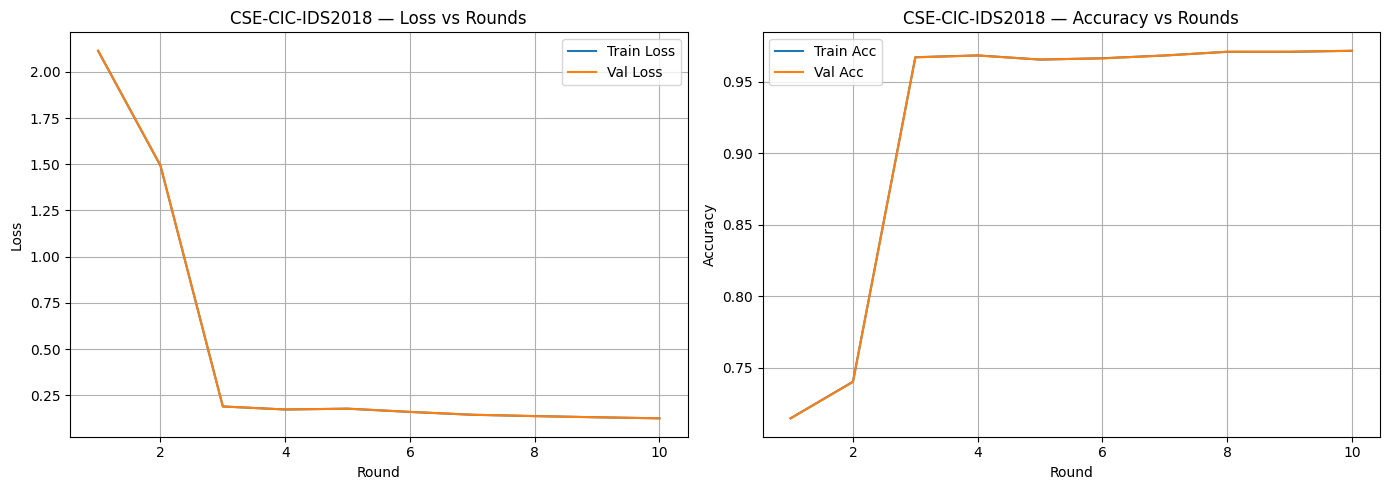


📈 FedAvg Convergence for CIC_IIoT_2025


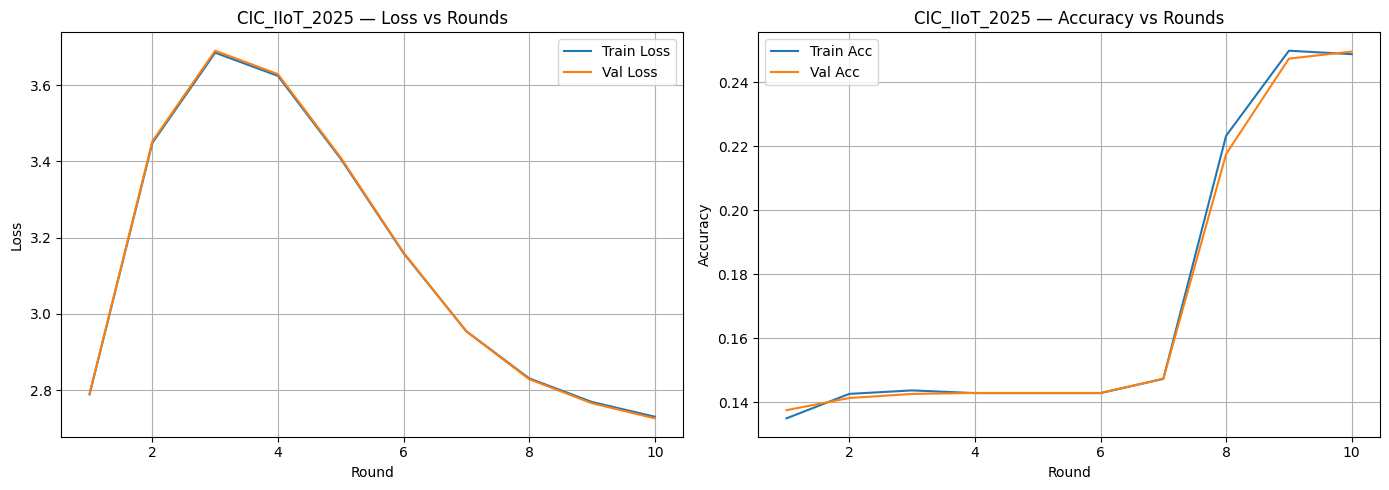


📈 FedAvg Convergence for CIC_BCCC_IoMT_2024


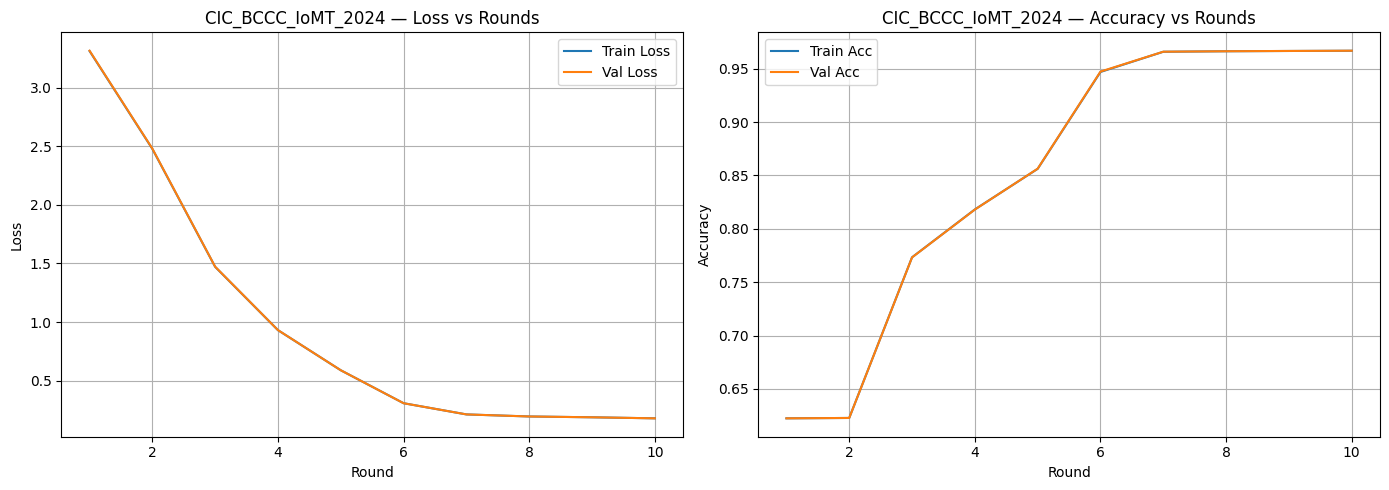


📈 FedAvg Convergence for Combined


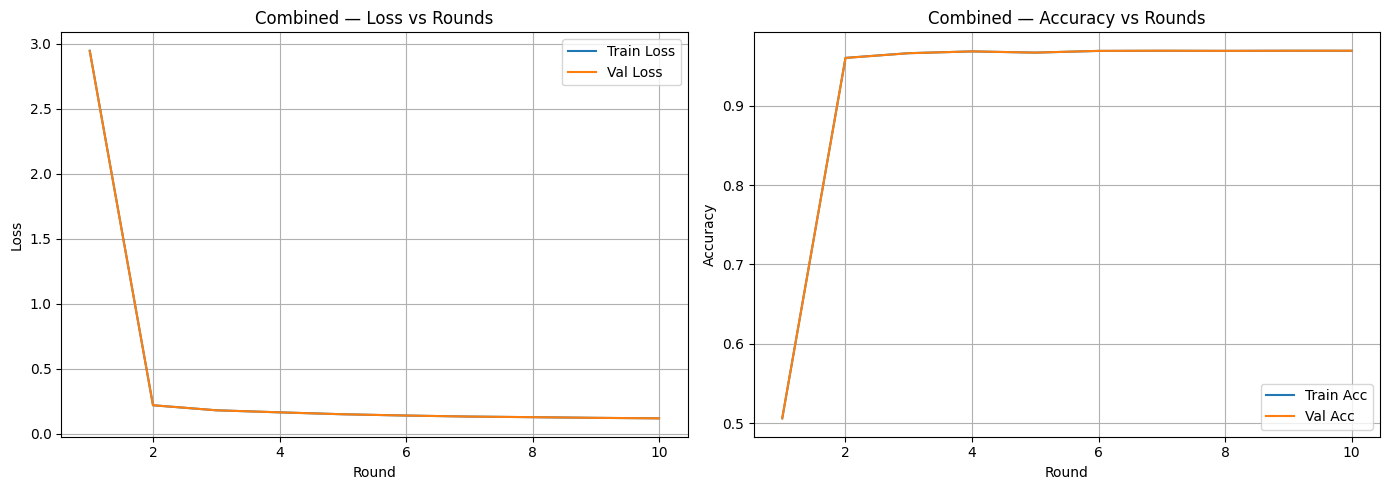

In [11]:
def plot_history_for_dataset(ds_name: str, history: Dict[str, List[float]]):
    rounds = history["round"]
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_acc = history["train_acc"]
    val_acc = history["val_acc"]

    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(rounds, train_loss, label="Train Loss")
    plt.plot(rounds, val_loss, label="Val Loss")
    plt.title(f"{ds_name} — Loss vs Rounds")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(rounds, train_acc, label="Train Acc")
    plt.plot(rounds, val_acc, label="Val Acc")
    plt.title(f"{ds_name} — Accuracy vs Rounds")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


for ds_name, hist in all_histories.items():
    print(f"\n📈 FedAvg Convergence for {ds_name}")
    plot_history_for_dataset(ds_name, hist)

In [12]:
import json
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

SAVE_BASE = "/users/"
os.makedirs(SAVE_BASE, exist_ok=True)

def save_federated_results(
    dataset_name: str,
    model: tf.keras.Model,
    history: Dict[str, List[float]]
):
    print(f"\n💾 Saving results for: {dataset_name}")

    # -----------------------------
    # Create dataset-specific folder
    # -----------------------------
    ds_save_dir = os.path.join(SAVE_BASE, dataset_name)
    os.makedirs(ds_save_dir, exist_ok=True)

    # -----------------------------
    # Re-load dataset to compute class metrics
    # -----------------------------
    X_train, X_val, X_test, y_train, y_val, y_test, num_classes = load_dataset(dataset_name)

    # -----------------------------
    # Evaluate model
    # -----------------------------
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Predictions on test
    y_pred_probs = model.predict(X_test, batch_size=256, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # -----------------------------
    # Compute class-wise metrics
    # -----------------------------
    class_report_dict = classification_report(
        y_test, y_pred, output_dict=True, zero_division=0
    )
    class_report_df = pd.DataFrame(class_report_dict).transpose()

    # -----------------------------
    # Confusion matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    # -----------------------------
    # Save the model (Keras format)
    # -----------------------------
    model_path = os.path.join(ds_save_dir, f"{dataset_name}_FALCON_ID_FedAvg.keras")
    model.save(model_path)
    print(f"✔ Saved global model: {model_path}")

    # -----------------------------
    # Save metrics (JSON)
    # -----------------------------
    metrics_out = {
        "dataset": dataset_name,
        "num_classes": num_classes,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "history": history,  # All FL rounds
    }
    metrics_path = os.path.join(ds_save_dir, "metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics_out, f, indent=4)
    print(f"✔ Saved metrics JSON: {metrics_path}")

    # -----------------------------
    # Save class-wise report (CSV)
    # -----------------------------
    classwise_path = os.path.join(ds_save_dir, "class_report.csv")
    class_report_df.to_csv(classwise_path)
    print(f"✔ Saved classwise metrics CSV: {classwise_path}")

    # -----------------------------
    # Save confusion matrix
    # -----------------------------
    cm_path = os.path.join(ds_save_dir, "confusion_matrix.npy")
    np.save(cm_path, cm)
    print(f"✔ Saved confusion matrix: {cm_path}")

    print(f"🎉 Completed saving all results for dataset: {dataset_name}\n")


In [13]:
for ds_name in DATASET_PATHS.keys():
    print("\n" + "=" * 100)
    print(f"💾 EXPORTING RESULTS FOR {ds_name}")
    print("=" * 100)

    save_federated_results(
        dataset_name=ds_name,
        model=all_models[ds_name],
        history=all_histories[ds_name]
    )

print("\n\n🎉🎉 ALL FEDERATED RESULTS SAVED SUCCESSFULLY! 🎉🎉")


💾 EXPORTING RESULTS FOR CSE-CIC-IDS2018

💾 Saving results for: CSE-CIC-IDS2018

📂 Loaded dataset: CSE-CIC-IDS2018
  Path: /users/
  X_train: (6737603, 64), X_val: (1443772, 64), X_test: (1443773, 64)
  y_train: (6737603,), y_val: (1443772,), y_test: (1443773,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
  Num classes: 15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (256, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


✔ Saved global model: /users/
✔ Saved metrics JSON: /users/
✔ Saved classwise metrics CSV: /users/
✔ Saved confusion matrix: /users/
🎉 Completed saving all results for dataset: CSE-CIC-IDS2018


💾 EXPORTING RESULTS FOR CIC_IIoT_2025

💾 Saving results for: CIC_IIoT_2025

📂 Loaded dataset: CIC_IIoT_2025
  Path: /users/
  X_train: (29424, 64), X_val: (6305, 64), X_test: (6306, 64)
  y_train: (29424,), y_val: (6305,), y_test: (6306,)
  Unique labels: [0 1 2 3 4 5 6]
  Num classes: 7


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (256, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


✔ Saved global model: /users/
✔ Saved metrics JSON: /users/
✔ Saved classwise metrics CSV: /users/
✔ Saved confusion matrix: /users/
🎉 Completed saving all results for dataset: CIC_IIoT_2025


💾 EXPORTING RESULTS FOR CIC_BCCC_IoMT_2024

💾 Saving results for: CIC_BCCC_IoMT_2024

📂 Loaded dataset: CIC_BCCC_IoMT_2024
  Path: /users/
  X_train: (2369719, 64), X_val: (507797, 64), X_test: (507797, 64)
  y_train: (2369719,), y_val: (507797,), y_test: (507797,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
  Num classes: 15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (256, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


✔ Saved global model: /users/
✔ Saved metrics JSON: /users/
✔ Saved classwise metrics CSV: /users/
✔ Saved confusion matrix: /users/
🎉 Completed saving all results for dataset: CIC_BCCC_IoMT_2024


💾 EXPORTING RESULTS FOR Combined

💾 Saving results for: Combined

📂 Loaded dataset: Combined
  Path: /users/
  X_train: (9136746, 64), X_val: (1957874, 64), X_test: (1957876, 64)
  y_train: (9136746,), y_val: (1957874,), y_test: (1957876,)
  Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36]
  Num classes: 37


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (256, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 16, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


✔ Saved global model: /users/
✔ Saved metrics JSON: /users/
✔ Saved classwise metrics CSV: /users/
✔ Saved confusion matrix: /users/
🎉 Completed saving all results for dataset: Combined



🎉🎉 ALL FEDERATED RESULTS SAVED SUCCESSFULLY! 🎉🎉
